# Visualization of Results

In [54]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
wandb.login()

True

## Global Settings

In [ ]:
color_mapping = {
    "UGS": "#377EB8",  # Muted blue
    "FPLS": "#4DAF4A",  # Muted green
    "FLS": "#984EA3",   # Muted purple
}

dataset = "ham10k"
B = 64
K = 16

dataset = "cifar10"
B = 128
K = 64

PROJECT_NAME = "inda/gpsl"

# Initialize a W&B API client
api = wandb.Api()

# Get all runs in the project
runs = api.runs(PROJECT_NAME)

## Batch Deviation

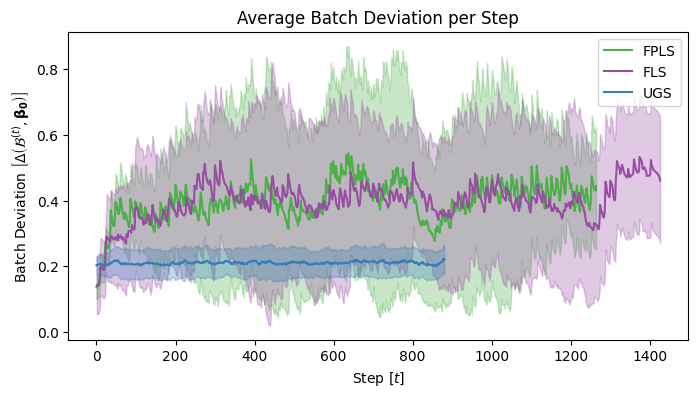

In [56]:
df = pd.DataFrame(
    columns=[
        "run_id",
        "method",
        "batch_size",
        "num_clients",
        "dataset",
        "batch_deviation",
        "step",  # add the missing column
    ]
)

for run in runs:
    data_config = run.config.get("data", None)
    distributed_config = run.config.get("distributed", None)
    if dataset not in data_config["_target_"].lower():
        continue

    if not int(data_config["batch_size"]) == B:
        continue

    if not int(distributed_config["num_clients"]) == K:
        continue

    # Load per-step history for batch_deviation
    history = run.history(keys=["train/batch_deviation"])
    for index, row in history.iterrows():
        new_row = {
            "run_id": run.id,
            "method": distributed_config["sampler"]["_target_"].split(".")[-1],
            "batch_size": data_config["batch_size"],
            "num_clients": distributed_config["num_clients"],
            "dataset": data_config["_target_"],
            "step": row.get("_step", None),
            "batch_deviation": row.get("train/batch_deviation", None)
        }
        df.loc[len(df)] = new_row
        
# Group by sampling method and step, then compute mean and std for batch_deviation
grouped = (
    df.groupby(["method", "step"])["batch_deviation"].agg(["mean", "std"]).reset_index()
)

# Rename methods for better readability
grouped["method"] = grouped["method"].replace(
    {
        "UniformGlobalSampler": "UGS",
        "LocalFixedSampler": "FPLS",
        "LocalFixedSamplerNonProportional": "FLS",
    }
)

smoothing_window = 50  # EMA span

methods = grouped["method"].unique()

plt.figure(figsize=(8, 4))

for method in methods:
    method_data = grouped[grouped["method"] == method].sort_values("step")
    smoothed_mean_ema = (
        method_data["mean"].ewm(span=smoothing_window, adjust=False).mean()
    )
    smoothed_std_ema = (
        method_data["std"].ewm(span=smoothing_window, adjust=False).mean()
    )
    # Use the specific color for each method (default to black if not specified)
    color = color_mapping.get(method, "#000000")
    plt.plot(
        method_data["step"], smoothed_mean_ema, label=method, color=color, linewidth=1.5
    )
    plt.fill_between(
        method_data["step"],
        smoothed_mean_ema - smoothed_std_ema,
        smoothed_mean_ema + smoothed_std_ema,
        color=color,
        alpha=0.3,
    )

plt.xlabel("Step $\left[t\\right]$")
plt.ylabel(
    "Batch Deviation $\left[ \Delta\left(\mathcal{B}^{(t)}, \\mathbf{\\beta_0}\\right) \\right]$"
)
plt.title("Average Batch Deviation per Step")
plt.legend()
plt.show()


## Training Time

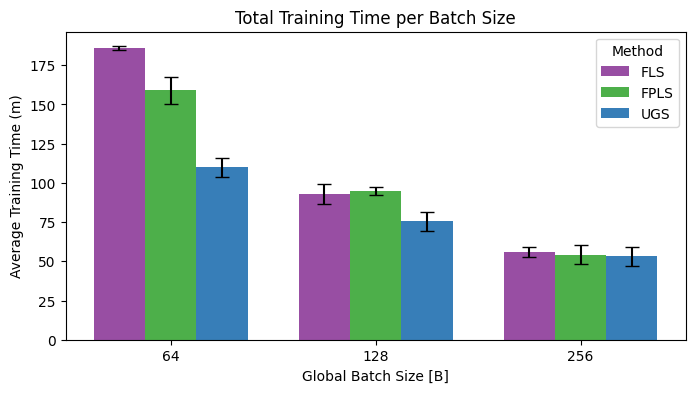

In [57]:
df = pd.DataFrame(
    columns=[
        "run_id",
        "method",
        "batch_size",
        "num_clients",
        "dataset",
        "runtime"
    ]
)

for run in runs:
    data_config = run.config.get("data", None)
    distributed_config = run.config.get("distributed", None)
    if dataset not in data_config["_target_"].lower():
        continue

    # if not int(data_config["batch_size"]) == B:
    #     continue

    if not int(distributed_config["num_clients"]) == K:
        continue
    
    runtime = run.summary.get("_runtime", None)
    
    new_row = {
        "run_id": run.id,
        "method": distributed_config["sampler"]["_target_"].split(".")[-1],
        "batch_size": data_config["batch_size"],
        "num_clients": distributed_config["num_clients"],
        "dataset": data_config["_target_"],
        "runtime": runtime
    }
    df.loc[len(df)] = new_row
    
# Group by batch size and method, then aggregate mean and standard deviation for runtime.
stats = df.groupby(["batch_size", "method"])["runtime"].agg(["mean", "std"]).reset_index()

# Rename methods for better readability using the provided mappings.
rename_mapping = {
    "UniformGlobalSampler": "UGS",
    "LocalFixedSampler": "FPLS",
    "LocalFixedSamplerNonProportional": "FLS"
}
stats["method"] = stats["method"].replace(rename_mapping)

# Convert runtime seconds to minutes for better readability.
stats["mean_sec"] = stats["mean"] / 60
stats["std_sec"] = stats["std"] / 60

# Define the desired order for the methods.
ordered_methods = ["FLS", "FPLS", "UGS"]
stats["method"] = pd.Categorical(stats["method"], categories=ordered_methods, ordered=True)
stats = stats.sort_values(["batch_size", "method"])

# Get unique batch sizes and prepare x-axis positions.
batch_sizes = stats["batch_size"].unique()
x = np.arange(len(batch_sizes))
width = 0.25  # width of each bar

plt.figure(figsize=(8, 4))
for i, method in enumerate(ordered_methods):
    subset = stats[stats["method"] == method].sort_values("batch_size")
    plt.bar(x + i * width, subset["mean_sec"], width,
            yerr=subset["std_sec"], capsize=5,
            label=method,
            color=color_mapping[method])

plt.xlabel("Global Batch Size [B]")
plt.ylabel("Average Training Time (m)")
plt.title("Total Training Time per Batch Size")
plt.xticks(x + width, batch_sizes)
plt.legend(title="Method")
plt.show()


## Test Accuracy

In [58]:
df = pd.DataFrame(
    columns=[
        "run_id",
        "method",
        "test_accuracy",
        "epoch"
    ]

)

for run in runs:
    data_config = run.config.get("data", None)
    distributed_config = run.config.get("distributed", None)
    if dataset not in data_config["_target_"].lower():
        continue
    
    # Load per-step history for test accuracy
    history = run.history(keys=["test/acc", "epoch"])
    for index, row in history.iterrows():
        new_row = {
            "run_id": run.id,
            "method": distributed_config["sampler"]["_target_"].split(".")[-1],
            "test_accuracy": row.get("test/acc", None),
            "epoch": row.get("epoch", None),
        }
        df.loc[len(df)] = new_row


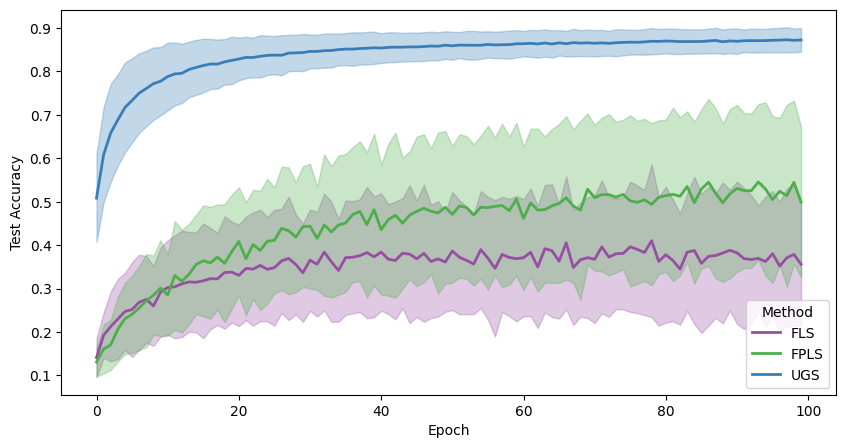

In [59]:
# Group by method and epoch, then compute the mean and std for test accuracy
grouped_accuracy = df.groupby(["method", "epoch"])["test_accuracy"].agg(["mean", "std"]).reset_index()

# Rename methods for better readability
rename_mapping = {
    "UniformGlobalSampler": "UGS",
    "LocalFixedSampler": "FPLS",
    "LocalFixedSamplerNonProportional": "FLS"
}
grouped_accuracy["method"] = grouped_accuracy["method"].replace(rename_mapping)

# Order the methods (FLS, FPLS, UGS)
ordered_methods = ["FLS", "FPLS", "UGS"]
grouped_accuracy["method"] = pd.Categorical(grouped_accuracy["method"], 
                                             categories=ordered_methods, 
                                             ordered=True)
grouped_accuracy = grouped_accuracy.sort_values(["epoch", "method"])

# Convert the epoch, mean, and std columns to numeric types
grouped_accuracy["epoch"] = pd.to_numeric(grouped_accuracy["epoch"], errors="coerce")
grouped_accuracy["mean"] = pd.to_numeric(grouped_accuracy["mean"], errors="coerce")
grouped_accuracy["std"] = pd.to_numeric(grouped_accuracy["std"], errors="coerce")

# Use the color mapping provided above
color_mapping = {
    "UGS": "#377EB8",  # Muted blue
    "FPLS": "#4DAF4A",  # Muted green
    "FLS": "#984EA3",   # Muted purple
}

plt.figure(figsize=(10, 5))
for method in ordered_methods:
    data = grouped_accuracy[grouped_accuracy["method"] == method].sort_values("epoch")
    plt.plot(data["epoch"], data["mean"], label=method, color=color_mapping[method], linewidth=2)
    plt.fill_between(data["epoch"].astype(float),
                     (data["mean"] - data["std"]).astype(float),
                     (data["mean"] + data["std"]).astype(float),
                     color=color_mapping[method],
                     alpha=0.3)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
# plt.title("Test Accuracy vs Epoch")
plt.legend(title="Method")
plt.show()

## Tables

In the following are our main table results that need to be filled with the results from the experiments in wandb:

In [60]:
# hparams

non_iid_degree = {
    "cifar10": {
        "mild": {"C": 5, "alpha": 3},
        "severe": {"C": 2, "alpha": 3},
    },
    "ham10k": {"mild": {"C": 5, "alpha": 10}, "severe": {"C": 3, "alpha": 10}},
}

df = pd.DataFrame(
    columns=[
        "run_id",
        "method",
        "test_accuracy",
        "batch_size",
        "num_clients",
        "C",
        "alpha",
    ]
)

for run in runs:
    data_config = run.config.get("data", None)
    distributed_config = run.config.get("distributed", None)
    if dataset not in data_config["_target_"].lower():
        continue

    new_row = {
        "run_id": run.id,
        "method": distributed_config["sampler"]["_target_"].split(".")[-1],
        "test_accuracy": run.summary.get("test/acc", None),
        "batch_size": data_config["batch_size"],
        "num_clients": distributed_config["num_clients"],
        "C": distributed_config["subset_config"]["params"]["C"],
        "alpha": distributed_config["subset_config"]["params"]["alpha"],
    }
    df.loc[len(df)] = new_row

/tmp/ipykernel_641468/3413491290.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[len(df)] = new_row


In [61]:
rename_mapping = {
    "UniformGlobalSampler": "UGS",
    "LocalFixedSampler": "FPLS",
    "LocalFixedSamplerNonProportional": "FLS"
}

df["method"] = df["method"].replace(rename_mapping)

# Use the non_iid_degree mapping to replace C and alpha columns with a single column that is "mild" or "severe"
def get_non_iid_degree(row):
    if row["C"] == non_iid_degree[dataset]["mild"]["C"] and row["alpha"] == non_iid_degree[dataset]["mild"]["alpha"]:
        return "mild"
    elif row["C"] == non_iid_degree[dataset]["severe"]["C"] and row["alpha"] == non_iid_degree[dataset]["severe"]["alpha"]:
        return "severe"
    else:
        return "unknown"
    
df["non_iid_degree"] = df.apply(get_non_iid_degree, axis=1)
# Convert the non_iid_degree column to a categorical type with a specific order
df["non_iid_degree"] = pd.Categorical(df["non_iid_degree"], categories=["mild", "severe"], ordered=True)

# Mean and std for test accuracy
grouped = df.groupby(["method", "non_iid_degree", "batch_size", "num_clients"])["test_accuracy"].agg(["mean", "std"]).reset_index()

# Prompt for filling in the missing values
prompt = "fill the table with the following values, make the best value per column bold: "

/tmp/ipykernel_641468/3495235740.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["method", "non_iid_degree", "batch_size", "num_clients"])["test_accuracy"].agg(["mean", "std"]).reset_index()


### Table II
$K \in \{16, 32, 64, 128\}$ 

$B = 128$

_severe_ non-iid

In [62]:
table2_df = grouped[
    (grouped["batch_size"] == 128)
    & (grouped["num_clients"].isin([16, 32, 64, 128]))
    & (grouped["non_iid_degree"] == "severe")
].copy()
table2_df = table2_df.sort_values(["num_clients", "method"])
table2_df["method"] = pd.Categorical(
    table2_df["method"], categories=["FLS", "FPLS", "UGS"], ordered=True
)
table2_df = table2_df.reset_index(drop=True)
table2_df = table2_df.drop(columns=["batch_size", "non_iid_degree"])
table2_df = table2_df.rename(
    columns={
        "num_clients": "K",
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
        "method": "Method",
    }
)
table2_df["Test Accuracy"] = table2_df["Test Accuracy"].round(4) * 100
table2_df["Test Accuracy Std"] = table2_df["Test Accuracy Std"].round(4) * 100

print(prompt + table2_df.to_json())

fill the table with the following values, make the best value per column bold: {"Method":{"0":"FLS","1":"FPLS","2":"UGS","3":"FLS","4":"FPLS","5":"UGS","6":"FLS","7":"FPLS","8":"UGS","9":"FLS","10":"FPLS","11":"UGS"},"K":{"0":16,"1":16,"2":16,"3":32,"4":32,"5":32,"6":64,"7":64,"8":64,"9":128,"10":128,"11":128},"Test Accuracy":{"0":34.76,"1":43.82,"2":89.55,"3":22.35,"4":61.22,"5":89.14,"6":22.94,"7":49.97,"8":89.63,"9":38.47,"10":59.3,"11":86.83},"Test Accuracy Std":{"0":null,"1":15.71,"2":0.59,"3":null,"4":5.9,"5":0.21,"6":null,"7":21.75,"8":0.55,"9":null,"10":13.69,"11":3.73}}


### Table III

$K \in \{16, 32, 64, 128\}$

$B = 128$

_mild_ non-iid

In [63]:
table3_df = grouped[
    (grouped["batch_size"] == 128)
    & (grouped["num_clients"].isin([16, 32, 64, 128]))
    & (grouped["non_iid_degree"] == "mild")
].copy()
table3_df = table3_df.sort_values(["num_clients", "method"])
table3_df["method"] = pd.Categorical(
    table3_df["method"], categories=["FLS", "FPLS", "UGS"], ordered=True
)
table3_df = table3_df.reset_index(drop=True)
table3_df = table3_df.drop(columns=["batch_size", "non_iid_degree"])
table3_df = table3_df.rename(
    columns={
        "num_clients": "K",
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
        "method": "Method",
    }
)
table3_df["Test Accuracy"] = table3_df["Test Accuracy"].round(4) * 100
table3_df["Test Accuracy Std"] = table3_df["Test Accuracy Std"].round(4) * 100
print(prompt + table3_df.to_json())

fill the table with the following values, make the best value per column bold: {"Method":{"0":"FLS","1":"FPLS","2":"UGS","3":"FLS","4":"FPLS","5":"UGS","6":"FLS","7":"FPLS","8":"UGS","9":"FLS","10":"FPLS","11":"UGS"},"K":{"0":16,"1":16,"2":16,"3":32,"4":32,"5":32,"6":64,"7":64,"8":64,"9":128,"10":128,"11":128},"Test Accuracy":{"0":51.51,"1":45.76,"2":86.54,"3":62.01,"4":47.52,"5":87.11,"6":41.43,"7":50.05,"8":86.7,"9":54.37,"10":25.91,"11":87.01},"Test Accuracy Std":{"0":null,"1":null,"2":2.74,"3":null,"4":null,"5":3.49,"6":null,"7":null,"8":3.19,"9":null,"10":null,"11":3.91}}


### Table IV

$K = 128$

$B \in \{64, 128, 256\}$

_severe_ non-iid

In [64]:
table4_df = grouped[
    (grouped["batch_size"].isin([64, 128, 256]))
    & (grouped["num_clients"] == 128)
    & (grouped["non_iid_degree"] == "severe")
].copy()
table4_df = table4_df.sort_values(["batch_size", "method"])
table4_df["method"] = pd.Categorical(
    table4_df["method"], categories=["FLS", "FPLS", "UGS"], ordered=True
)
table4_df = table4_df.reset_index(drop=True)
table4_df = table4_df.drop(columns=["num_clients", "non_iid_degree"])
table4_df = table4_df.rename(
    columns={
        "batch_size": "B",
        "mean": "Test Accuracy",
        "std": "Test Accuracy Std",
        "method": "Method",
    }
)
table4_df["Test Accuracy"] = table4_df["Test Accuracy"].round(4) * 100
table4_df["Test Accuracy Std"] = table4_df["Test Accuracy Std"].round(4) * 100
print(prompt + table4_df.to_json())

fill the table with the following values, make the best value per column bold: {"Method":{"0":"FLS","1":"FPLS","2":"UGS","3":"FLS","4":"FPLS","5":"UGS","6":"FLS","7":"FPLS","8":"UGS"},"B":{"0":64,"1":64,"2":64,"3":128,"4":128,"5":128,"6":256,"7":256,"8":256},"Test Accuracy":{"0":29.87,"1":47.9,"2":90.04,"3":38.47,"4":59.3,"5":86.83,"6":20.23,"7":56.88,"8":85.75},"Test Accuracy Std":{"0":null,"1":37.55,"2":0.3,"3":null,"4":13.69,"5":3.73,"6":null,"7":21.5,"8":3.52}}
